In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create images folder automatically
os.makedirs("images", exist_ok=True)

sns.set_theme(style="whitegrid")

In [ ]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 14.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.6/31.6 MB 7.8 MB/s eta 0:00:0000:0100:01m


In [2]:
df = pd.read_csv("data/Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
df.info()
df.isnull().sum()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 15.8 KB


(400, 5)

In [4]:
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])   # Male/Female → 0/1

df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,1,19,19000,0
1,15810944,1,35,20000,0
2,15668575,0,26,43000,0
3,15603246,0,27,57000,0
4,15804002,1,19,76000,0


In [5]:
X = df[["Gender", "Age", "EstimatedSalary"]]
y = df["Purchased"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [7]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [8]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc*100,2), "%")

Accuracy: 92.0 %


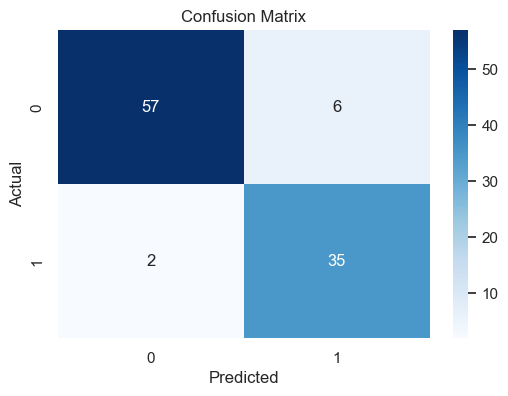

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("images/confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

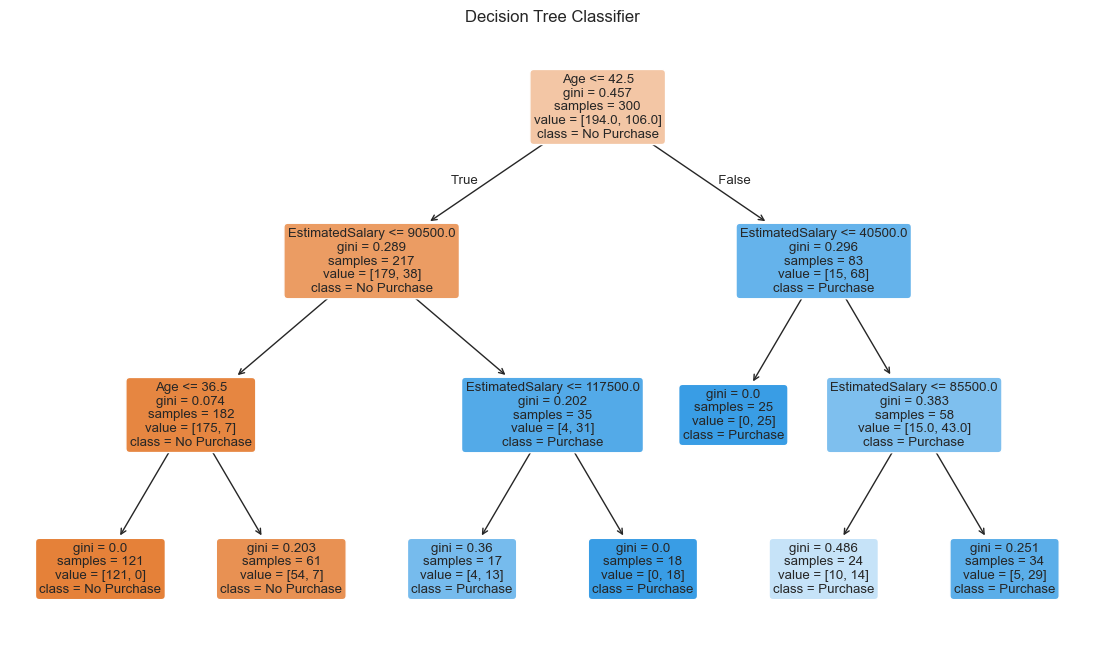

In [10]:
plt.figure(figsize=(14,8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No Purchase", "Purchase"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree Classifier")

plt.savefig("images/decision_tree.png", dpi=300, bbox_inches='tight')
plt.show()